# Диагностика качества карточек Wildberries — сводный отчёт

Групповой проект ВШЭ по Deep Learning на данных Wildberries: две связанные задачи на общих товарах, ключ связи nmId. Табличная модель по атрибутам карточки прогнозирует средний рейтинг и показывает, какие карточки в зоне риска, текстовая по отзывам ставит оценку 1–5 и достаёт аспекты недовольства, то есть почему рейтинг проседает. Этот ноутбук ничего не обучает: он сводит результаты обоих этапов из логов DagsHub в один итог, показывает связь моделей по nmId и проверяет, что метрики воспроизводятся только из логов, без локального поиска данных. Само обучение табличной задачи — в notebooks/tabular_mlp.ipynb, текстовой — в notebooks/text_dl.ipynb

In [1]:
import json
import os
import warnings

warnings.filterwarnings("ignore")
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"
os.environ["MLFLOW_SUPPRESS_PRINTING_URL_TO_STDOUT"] = "true"

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv
from IPython.display import display
from mlflow.tracking import MlflowClient
from sklearn.metrics import f1_score
from torch import nn

from src.utils import ROOT, load_config

cfg = load_config()
seed = cfg["random_seed"]
EXP_TAB = cfg["mlflow"]["experiment_tabular"]
EXP_TXT = cfg["mlflow"]["experiment_text"]

load_dotenv(ROOT / ".env")
mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
client = MlflowClient()
print("трекинг DagsHub подключён | эксперименты:", EXP_TAB, "и", EXP_TXT)

трекинг DagsHub подключён | эксперименты: wb-tabular-rating и wb-review-sentiment


## Результаты обеих задач из логов

Подключаемся к трекингу DagsHub и тянем все раны двух экспериментов. Таблицы сравнения ниже собраны не из памяти, а прямо из метрик, записанных в каждый ран на этапах 4 и 5. Раны с одинаковым именем (перезапуски) схлопываем до самого свежего

In [2]:
def runs_df(experiment):
    exp = client.get_experiment_by_name(experiment)
    runs = client.search_runs([exp.experiment_id], order_by=["start_time DESC"], max_results=500)
    seen, rows = set(), []
    for r in runs:
        name = r.data.tags.get("mlflow.runName")
        if name in seen:
            continue
        seen.add(name)
        rows.append({"run": name, **r.data.metrics})
    return pd.DataFrame(rows)


tab = runs_df(EXP_TAB)
txt = runs_df(EXP_TXT)
print("ранов в табличном эксперименте:", len(tab), "| в текстовом:", len(txt))

ранов в табличном эксперименте: 14 | в текстовом: 11


## Табличная задача — рейтинг карточки

Регрессия среднего рейтинга по атрибутам карточки, метрика RMSE. Целевая узкая, почти весь каталог это карточки 4.5–5.0, поэтому даже константа даёт около 0.15 и борьба идёт за сотые — ценность модели в ранжировании редкого проблемного хвоста, а не в точном среднем. На валидации сравниваем бейзлайны без сети и четыре конфигурации MLP с сеткой гиперпараметров, на test показываем итог

In [3]:
tab_val = tab[~tab["run"].isin(["final_test", "dataset"])].copy()
tab_val["val_rmse"] = tab_val["best_val_rmse"].fillna(tab_val["val_rmse"])
tab_val["val_mae"] = tab_val["best_val_mae"].fillna(tab_val["val_mae"])
val_table = (
    tab_val[["run", "val_rmse", "val_mae"]]
    .sort_values("val_rmse").round(4).reset_index(drop=True)
)
display(val_table)

ft = tab[tab["run"] == "final_test"].iloc[0]
tab_test_table = pd.DataFrame([
    {"модель": "среднее по train", "test_rmse": round(ft["test_rmse_mean"], 4), "test_mae": round(ft["test_mae_mean"], 4)},
    {"модель": "градиентный бустинг", "test_rmse": round(ft["test_rmse_baseline"], 4), "test_mae": round(ft["test_mae_baseline"], 4)},
    {"модель": "MLP [64]", "test_rmse": round(ft["test_rmse"], 4), "test_mae": round(ft["test_mae"], 4)},
])
tab_test_table

,run,val_rmse,val_mae
0,mlp_small,0.1274,0.0875
1,mlp_small_lr0.001_wd0.0001,0.1282,0.0892
2,mlp_small_lr0.003_wd0.0001,0.1286,0.0883
3,mlp_small_lr0.003_wd0.0,0.1287,0.0884
4,mlp_small_lr0.0003_wd0.0,0.1289,0.0909
5,mlp_small_lr0.0003_wd0.0001,0.1291,0.0932
6,baseline_gb,0.1295,0.0888
7,baseline_ridge,0.1298,0.0916
8,baseline_mean,0.1399,0.1065
9,mlp_bn_gelu,0.1432,0.1088


,модель,test_rmse,test_mae
0,среднее по train,0.1511,0.1058
1,градиентный бустинг,0.1418,0.0871
2,MLP [64],0.1448,0.0900


## Текстовая задача — оценка отзыва

Классификация оценки отзыва 1–5, метрика macro-F1 из-за сильного перекоса в сторону пятёрок. Четыре значимо разные архитектуры на одних сплитах: TF-IDF с логрегом без сети, свёрточная сеть, двунаправленный LSTM и дообучение трансформера ruBERT-tiny2. Слева валидация, справа итог на отложенном test

In [4]:
txt_val = txt[~txt["run"].isin(["final_test", "dataset"])].copy()
txt_val["val_macro_f1"] = txt_val["best_val_macro_f1"].fillna(txt_val["val_macro_f1"])
txt_val_table = (
    txt_val[["run", "val_macro_f1"]]
    .sort_values("val_macro_f1", ascending=False).round(4).reset_index(drop=True)
)
display(txt_val_table)

ftt = txt[txt["run"] == "final_test"].iloc[0]
txt_test_table = pd.DataFrame([
    {"архитектура": "tf-idf + логрег", "test_macro_f1": round(ftt["test_macro_f1_tfidf"], 4)},
    {"архитектура": "rubert-tiny2", "test_macro_f1": round(ftt["test_macro_f1_bert"], 4)},
    {"архитектура": "cnn-text", "test_macro_f1": round(ftt["test_macro_f1_cnn"], 4)},
    {"архитектура": "bilstm", "test_macro_f1": round(ftt["test_macro_f1_bilstm"], 4)},
]).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
txt_test_table

,run,val_macro_f1
0,tfidf_logreg,0.5116
1,bert_tiny_lr5e5_len64,0.4907
2,bilstm,0.4846
3,bilstm_lr0.002_do0.5,0.4800
4,bilstm_lr0.0005_do0.3,0.4785
5,bert_tiny,0.4749
6,bilstm_lr0.002_do0.3,0.4704
7,bilstm_lr0.0005_do0.5,0.4682
8,cnn,0.4654


,архитектура,test_macro_f1
0,tf-idf + логрег,0.5159
1,rubert-tiny2,0.5011
2,cnn-text,0.4685
3,bilstm,0.4591


## Единый итог

Сводим обе задачи в одну таблицу: точка отсчёта без сети, DL-модель и победитель на отложенном test. Любопытный общий результат — в обеих задачах классика без глубокого обучения оказалась не хуже сети, и это честный вывод по объёму данных, а не недоработка

In [5]:
unified = pd.DataFrame([
    {"задача": "рейтинг карточки (таблица)", "метрика": "RMSE", "лучше когда": "меньше",
     "без сети": round(ft["test_rmse_baseline"], 4), "DL-модель": round(ft["test_rmse"], 4),
     "победитель": "градиентный бустинг"},
    {"задача": "оценка отзыва (текст)", "метрика": "macro-F1", "лучше когда": "больше",
     "без сети": round(ftt["test_macro_f1_tfidf"], 4), "DL-модель": round(ftt["test_macro_f1_bert"], 4),
     "победитель": "tf-idf + логрег"},
])
unified

,задача,метрика,лучше когда,без сети,DL-модель,победитель
0,рейтинг карточки (таблица),RMSE,меньше,0.1418,0.1448,градиентный бустинг
1,оценка отзыва (текст),macro-F1,больше,0.5159,0.5011,tf-idf + логрег


## Данные и воспроизводимость только из логов

Сильное требование к воспроизводимости: в DagsHub лежат не только модели, но и сами сплиты train/val/test, выложены как артефакты ран dataset в каждом эксперименте скриптом src/log_datasets.py. Значит любой результат повторяется без локальных данных — скачиваем сплиты и веса прямо из логов в data/from_logs и пересчитываем метрику победителя каждой задачи

In [6]:
DST = ROOT / "data" / "from_logs"
DST.mkdir(parents=True, exist_ok=True)


def run_id(experiment, name):
    exp = client.get_experiment_by_name(experiment)
    found = client.search_runs(
        [exp.experiment_id], filter_string=f"tags.mlflow.runName = '{name}'",
        order_by=["start_time DESC"], max_results=1,
    )
    return found[0].info.run_id


def pull(rid, artifact):
    mlflow.artifacts.download_artifacts(run_id=rid, artifact_path=artifact, dst_path=str(DST))


tab_data, txt_data = run_id(EXP_TAB, "dataset"), run_id(EXP_TXT, "dataset")
for f in ["tabular_train.parquet", "tabular_val.parquet", "tabular_test.parquet"]:
    pull(tab_data, "data/" + f)
for f in ["text_train.parquet", "text_val.parquet", "text_test.parquet"]:
    pull(txt_data, "data/" + f)
for a in ["mlp_best.pt", "mlp_best.json", "tabular_preprocessor.joblib", "permutation_importance.csv"]:
    pull(run_id(EXP_TAB, "final_test"), a)
pull(run_id(EXP_TXT, "tfidf_logreg"), "text_tfidf_logreg.joblib")

print("скачано из логов в", DST.relative_to(ROOT))
print("сплиты:", sorted(p.name for p in DST.glob("*.parquet")))

скачано из логов в data/from_logs
сплиты: ['tabular_test.parquet', 'tabular_train.parquet', 'tabular_val.parquet', 'text_test.parquet', 'text_train.parquet', 'text_val.parquet']


In [7]:
DATA = DST
cat_tr = pd.read_parquet(DATA / "tabular_train.parquet")
cat_va = pd.read_parquet(DATA / "tabular_val.parquet")
cat_te = pd.read_parquet(DATA / "tabular_test.parquet")
rev_tr = pd.read_parquet(DATA / "text_train.parquet")
rev_va = pd.read_parquet(DATA / "text_val.parquet")
rev_te = pd.read_parquet(DATA / "text_test.parquet")


class MLP(nn.Module):
    def __init__(self, in_dim, hidden):
        super().__init__()
        layers = []
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


meta = json.loads((DST / "mlp_best.json").read_text())
pre = joblib.load(DST / "tabular_preprocessor.joblib")


def to_tensor(df):
    X = pre.transform(df)
    X = X.toarray() if hasattr(X, "toarray") else X
    return torch.tensor(X.astype(np.float32))


Xte = to_tensor(cat_te)
model = MLP(Xte.shape[1], meta["hidden"])
model.load_state_dict(torch.load(DST / "mlp_best.pt", weights_only=True))
model.eval()
with torch.no_grad():
    mlp_pred = model(Xte).numpy()
mlp_rmse = float(np.sqrt(np.mean((mlp_pred - cat_te["rating"].to_numpy()) ** 2)))

bundle = joblib.load(DST / "text_tfidf_logreg.joblib")
tfidf_pred = bundle["model"].predict(bundle["tfidf"].transform(rev_te["text_norm"]))
tfidf_f1 = f1_score(rev_te["mark"] - 1, tfidf_pred - 1, average="macro")

print("таблица, MLP RMSE из логов:", round(mlp_rmse, 4), "| в логах final_test:", round(ft["test_rmse"], 4))
print("текст, tf-idf macro-F1 из логов:", round(tfidf_f1, 4), "| в логах final_test:", round(ftt["test_macro_f1_tfidf"], 4))

таблица, MLP RMSE из логов: 0.1448 | в логах final_test: 0.1448
текст, tf-idf macro-F1 из логов: 0.5159 | в логах final_test: 0.5159


## Что определяет рейтинг — важность признаков из логов

Из логов же берём permutation importance лучшей модели на test: насколько растёт RMSE, если перемешать один признак. Это объясняет, по каким атрибутам табличная модель находит зону риска — бренд весит больше всех остальных признаков вместе, дальше число отзывов, а косметика карточки вроде числа фото и длины названия рейтинг почти не двигает

In [8]:
imp = pd.read_csv(DST / "permutation_importance.csv")
imp

,признак,прирост_rmse
0,brand,0.0124
1,n_reviews,0.0040
2,category,0.0026
3,price,0.0023
4,n_photos,0.0012
5,title_len,0.0001
6,n_colors,0.0000


## Связь задач по nmId

Здесь две модели соединяются. Табличная скорит весь каталог и ранжирует карточки по прогнозному рейтингу, текстовая по отзывам тех же nmId говорит, на что жалуются. Берём карточки с самым низким прогнозным рейтингом, у которых есть отзывы, и подставляем их главную жалобу из негативных отзывов — получается приоритет, какую карточку чинить и что именно в ней не так

In [9]:
catalog = pd.concat([cat_tr, cat_va, cat_te], ignore_index=True)
reviews = pd.concat([rev_tr, rev_va, rev_te], ignore_index=True)

with torch.no_grad():
    catalog["pred_rating"] = model(to_tensor(catalog)).numpy()

CAT = {"glasses": "очки", "phone_cases": "чехлы", "hangers": "вешалки"}
ASP = {"aspect_defect": "брак", "aspect_size": "размер", "aspect_delivery": "доставка",
       "aspect_quality": "качество", "aspect_price": "цена"}
aspect_cols = list(ASP)


def main_complaint(nm):
    sub = reviews[reviews["nmId"] == nm]
    neg = sub[sub["mark"] <= 2]
    base = neg if len(neg) else sub
    shares = base[aspect_cols].mean()
    return ASP[shares.idxmax()] if shares.max() > 0 else "—"


reviewed = catalog[catalog["nmId"].isin(reviews["nmId"])]
risk = reviewed.sort_values("pred_rating").head(10).copy()
risk["категория"] = risk["category"].map(CAT)
risk["главная жалоба"] = risk["nmId"].map(main_complaint)
print("карточек в каталоге:", len(catalog), "| из них с отзывами:", len(reviewed))
risk[["nmId", "категория", "brand", "n_reviews", "rating", "pred_rating", "главная жалоба"]].round(
    {"pred_rating": 3}
).reset_index(drop=True)

карточек в каталоге: 10443 | из них с отзывами: 1115


,nmId,категория,brand,n_reviews,rating,pred_rating,главная жалоба
0,28773347,вешалки,Soft Story,5,4.2,4.428,—
1,68135463,вешалки,Normalno,3393,4.4,4.443,качество
2,161590786,очки,L R,1191,4.6,4.456,цена
3,43802423,вешалки,SAVANNA,23,4.4,4.465,—
4,145225788,очки,J&K sunglasses,102,4.5,4.511,размер
5,148846261,вешалки,LE-DI,2296,4.5,4.531,качество
6,192618582,вешалки,Вешалка для одежды,31,4.5,4.532,качество
7,193143755,вешалки,ZABOZA,4235,4.5,4.534,качество
8,176729710,чехлы,FREEBIE,152,4.8,4.550,—
9,37174892,вешалки,Мыштон House,505,4.5,4.554,брак


## Аспекты недовольства по трём категориям

На негативных отзывах (оценка 1–2) считаем долю пяти аспектов по словарю лемм с этапа 3. Разрез по очкам, чехлам и вешалкам сразу показывает, что причины недовольства в категориях разные, и это прямой ответ текстовой модели на вопрос табличной — почему карточка в зоне риска

,категория,негативных,брак,размер,доставка,качество,цена
0,очки,2212,0.258,0.087,0.081,0.127,0.140
1,чехлы,1922,0.148,0.148,0.062,0.102,0.133
2,вешалки,1642,0.219,0.051,0.110,0.272,0.149


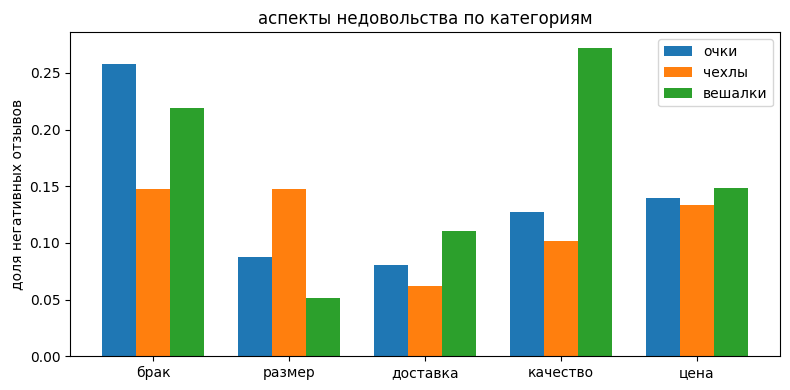

In [10]:
neg = reviews[reviews["mark"] <= 2]
rows = []
for cat, title in CAT.items():
    s = neg[neg["category"] == cat]
    row = {"категория": title, "негативных": len(s)}
    for col, name in ASP.items():
        row[name] = round(float(s[col].mean()), 3)
    rows.append(row)
aspect_table = pd.DataFrame(rows)
display(aspect_table)

x = np.arange(len(ASP))
width = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
for i, (cat, title) in enumerate(CAT.items()):
    s = neg[neg["category"] == cat]
    ax.bar(x + (i - 1) * width, [s[c].mean() for c in aspect_cols], width, label=title)
ax.set_xticks(x, list(ASP.values()))
ax.set_ylabel("доля негативных отзывов")
ax.set_title("аспекты недовольства по категориям")
ax.legend()
plt.tight_layout()
plt.show()

## Финальные выводы

Табличная задача: MLP [64] даёт на test RMSE 0.1448 против 0.1511 у константы — сеть уверенно бьёт точку отсчёта, но градиентный бустинг с теми же признаками чуть точнее (0.1418), и на 7 тысячах строк устойчивого преимущества у сети нет, для продакшена разумнее бустинг, а MLP остаётся корректной DL-демонстрацией. По важности признаков рейтинг почти целиком определяет продавец: бренд весит больше всех остальных признаков вместе, дальше число отзывов, а косметика карточки вроде числа фото и длины названия рейтинг не двигает. Текстовая задача: на test классика держит первое место — TF-IDF с логрегом 0.516 macro-F1, дообученный ruBERT-tiny2 почти догоняет (0.501), свои сети по эмбеддингам отстают (CNN 0.469, BiLSTM 0.459), потому что отзывы короткие и сигнал несут отдельные слова и биграммы, которые линейная модель снимает без потерь, так что глубина сама по себе тут не выигрывает, а ruBERT это выбор на вырост, когда отзывов станет кратно больше. Аспекты недовольства по категориям разные: в очках главная боль брак (25.8%) — сломанные дужки и треснувшие стёкла, в чехлах перекос к посадке (брак и размер по 14.8%) — несоответствие карточки реальному телефону, в вешалках лидируют качество (27.2%) и брак (21.9%) — хлипкая конструкция и запах пластика, а доставка и цена вторичны везде. Связка работает так: табличная модель по атрибутам показывает, какие карточки в зоне риска по рейтингу, а текстовая по отзывам тех же nmId объясняет причину — это и есть готовый для бизнеса приоритет, что чинить и почему